<a href="https://colab.research.google.com/github/TriBot2o/AI_And_ML_Year3/blob/main/Worksheet_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task-1


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image

train_dir = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon/test"

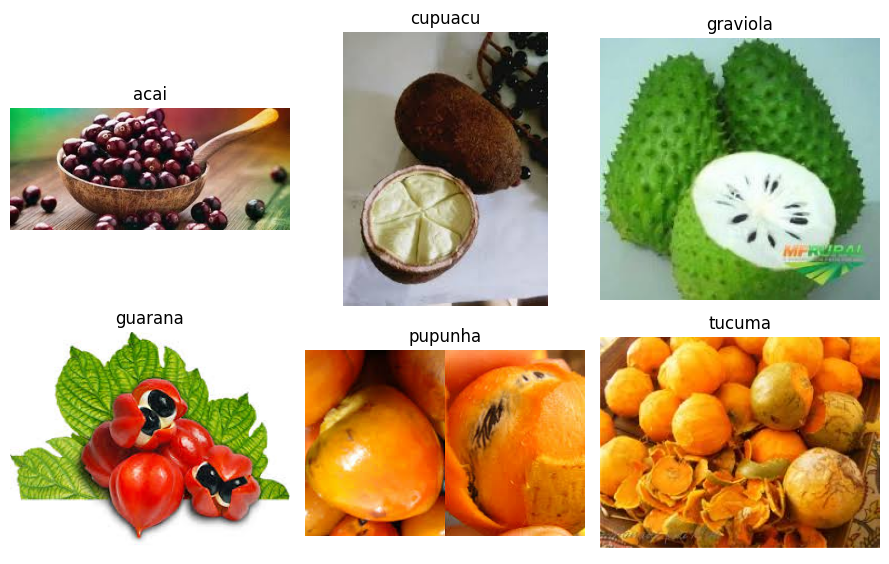

In [2]:
import random

# Get the list of class directories from the train folder
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# Lists to store paths of selected images and their labels
selected_image_paths = []
selected_labels = []

# Select one image randomly from each class
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    # Get all image files in the class directory
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpeg'))]

    if image_files:
        # Select one random image file path
        random_image_file = random.choice(image_files)
        img_path = os.path.join(class_path, random_image_file)
        selected_image_paths.append(img_path)
        selected_labels.append(class_name)

# Display the images in a grid format with two rows using matplotlib
num_images = len(selected_image_paths)
if num_images == 0:
    print("No images found to display.")
else:
    num_rows = 2
    # Calculate number of columns needed to fit all images in 2 rows
    num_cols = (num_images + num_rows - 1) // num_rows

    plt.figure(figsize=(num_cols * 3, num_rows * 3))

    for i, img_path in enumerate(selected_image_paths):
        plt.subplot(num_rows, num_cols, i + 1)
        try:
            img = Image.open(img_path)
            plt.imshow(img)
            plt.title(selected_labels[i])
            plt.axis('off')
        except Exception as e:
            print(f"Could not load image {img_path}: {e}")
            plt.title(f"Error: {selected_labels[i]}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()


In [3]:
def check_and_remove_corrupted_images(directory):
    corrupted_images_found = False
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpeg')):
                image_path = os.path.join(root, file)
                try:
                    with Image.open(image_path) as img:
                        img.verify()  # Verify the image data
                except (IOError, SyntaxError) as e:
                    print(f"Removed corrupted image: {image_path} (Error: {e})")
                    os.remove(image_path)
                    corrupted_images_found = True
                except Exception as e:
                    # Catch other potential errors during loading/verification
                    print(f"Removed problematic image: {image_path} (Unexpected Error: {e})")
                    os.remove(image_path)
                    corrupted_images_found = True

    if not corrupted_images_found:
        print("No Corrupted Images Found.")

check_and_remove_corrupted_images(train_dir)


No Corrupted Images Found.


In [4]:
class_counts = {}
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        # Filter for only .jpeg files, ignoring case
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpeg'))]
        count = len(images)
        class_counts[class_name] = count
        print(f"Class '{class_name}': {count} images")

# Display summary statistics if desired
total_images = sum(class_counts.values())
num_classes = len(class_counts)
print(f"\nTotal images in training set: {total_images}")
print(f"Number of classes: {num_classes}")

Class 'graviola': 15 images
Class 'cupuacu': 15 images
Class 'guarana': 15 images
Class 'acai': 15 images
Class 'pupunha': 15 images
Class 'tucuma': 15 images

Total images in training set: 90
Number of classes: 6


In [5]:
# Define image dimensions and batch size
image_size = (224, 224)  # Resize images to 224x224 pixels to match VGG16 input
batch_size = 32

# Create an ImageDataGenerator for data augmentation and preprocessing
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,            # Normalize pixel values to [0, 1]
    rotation_range=20,         # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,     # Randomly shift images horizontally by up to 20% of the width
    height_shift_range=0.2,    # Randomly shift images vertically by up to 20% of the height
    shear_range=0.2,           # Apply random shear transformations
    zoom_range=0.2,            # Randomly zoom into images
    horizontal_flip=True,      # Randomly flip images horizontally
    fill_mode='nearest'        # Fill any newly created pixels after transformations
)

# ImageDataGenerator for validation/test data (only rescaling)
validation_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

In [6]:
# Create training data generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'  # For multi-class classification
)

Found 90 images belonging to 6 classes.


In [7]:
# Create validation data generator
validation_generator = validation_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 30 images belonging to 6 classes.


In [8]:
# Define the CNN model architecture
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5), # Add dropout for regularization
    tf.keras.layers.Dense(len(class_names), activation='softmax') # Output layer with softmax activation
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,402,118 (169.38 MB)

 Trainable params: 44,400,646 (169.38 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [9]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size, # Number of steps per epoch
    epochs=25, # Number of epochs to train
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size # Number of validation steps
)

Epoch 1/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 30s 18s/step - accuracy: 0.2759 - loss: 3.3752 - val_accuracy: 0.2667 - val_loss: 3.1871
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.3750 - loss: 4.1683 - val_accuracy: 0.2667 - val_loss: 2.4680
Epoch 3/25


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 724ms/step - accuracy: 0.6724 - loss: 1.4148 - val_accuracy: 0.4333 - val_loss: 1.5265
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7188 - loss: 1.4617 - val_accuracy: 0.4000 - val_loss: 1.4225
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step - accuracy: 0.7586 - loss: 1.1474 - val_accuracy: 0.3667 - val_loss: 1.6386
Epoch 6/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step - accuracy: 0.5625 - loss: 2.2202 - val_accuracy: 0.3667 - val_loss: 1.9100
Epoch 7/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6379 - loss: 1.1569 - val_accuracy: 0.2333 - val_loss: 2.4931
Epoch 8/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step - accuracy: 0.7188 - loss: 1.2825 - val_accuracy: 0.2333 - val_loss: 2.6164
Epoch 9/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step - accuracy: 0.5862 - loss: 1.3066 - val_accuracy: 0.2667 - val_loss: 2.6425
Epoch 10/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.6875 - loss: 1.5290 - val_accuracy: 0.2667 - val_loss: 2.5578
Epoch

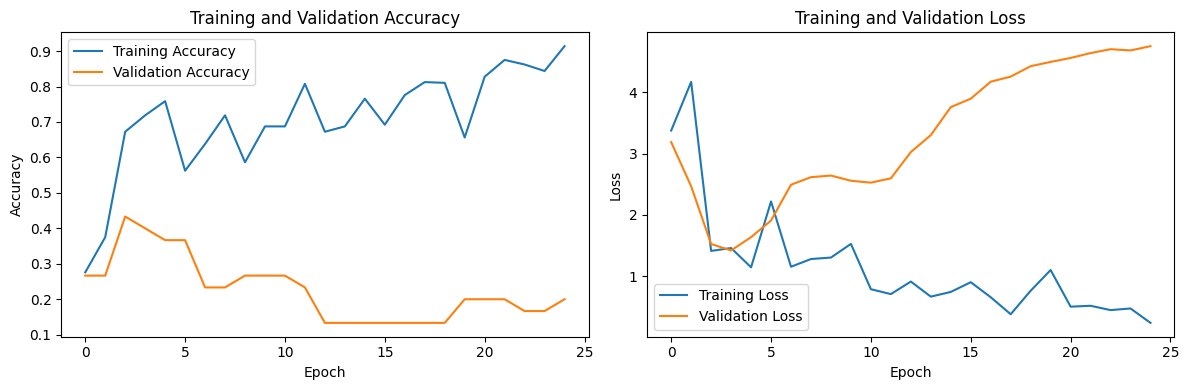

In [10]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# Evaluate the model on the validation set
print("\nEvaluating Model on Validation Set")
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")


Evaluating Model on Validation Set
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.2000 - loss: 4.7505
Validation Loss: 4.7505
Validation Accuracy: 0.2000


#Task-2

In [12]:
from tensorflow.keras.applications import VGG16
# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
# Freeze the layers of the base model
for layer in base_model.layers:
  layer.trainable = False

In [14]:
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D, BatchNormalization

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x) # Add Batch Normalization
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x) # Add Batch Normalization
x = Dense(len(class_names), activation='softmax') (x) # Corrected to match number of classes

In [15]:
from tensorflow.keras.models import Model
# Create the final model
model = Model(inputs=base_model.input, outputs=x)

In [16]:
from tensorflow.keras.optimizers import Adam
# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy']) # Corrected quotes

# Re-train the model after adding BatchNormalization
history_vgg = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size, # Number of steps per epoch
    epochs=25, # Number of epochs to train
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size # Number of validation steps
)

Epoch 1/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 29s 13s/step - accuracy: 0.3281 - loss: 1.9608 - val_accuracy: 0.2667 - val_loss: 1.7681
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 320ms/step - accuracy: 0.4615 - loss: 2.1270 - val_accuracy: 0.2667 - val_loss: 1.7143
Epoch 3/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step - accuracy: 0.7931 - loss: 0.5341 - val_accuracy: 0.3000 - val_loss: 1.6227
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step - accuracy: 0.8125 - loss: 0.4726 - val_accuracy: 0.3000 - val_loss: 1.5883
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 942ms/step - accuracy: 0.9310 - loss: 0.1343 - val_accuracy: 0.3667 - val_loss: 1.5422
Epoch 6/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 318ms/step - accuracy: 0.9062 - loss: 0.3252 - val_accuracy: 0.4000 - val_loss: 1.5274
Epoch 7/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 955ms/step - accuracy: 0.9310 - loss: 0.1548 - val_accuracy: 0.4000 - val_loss: 1.5022
Epoch 8/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step - accuracy: 0.9688 - loss: 0.1335 - val_accuracy: 0.4000 - val_loss:

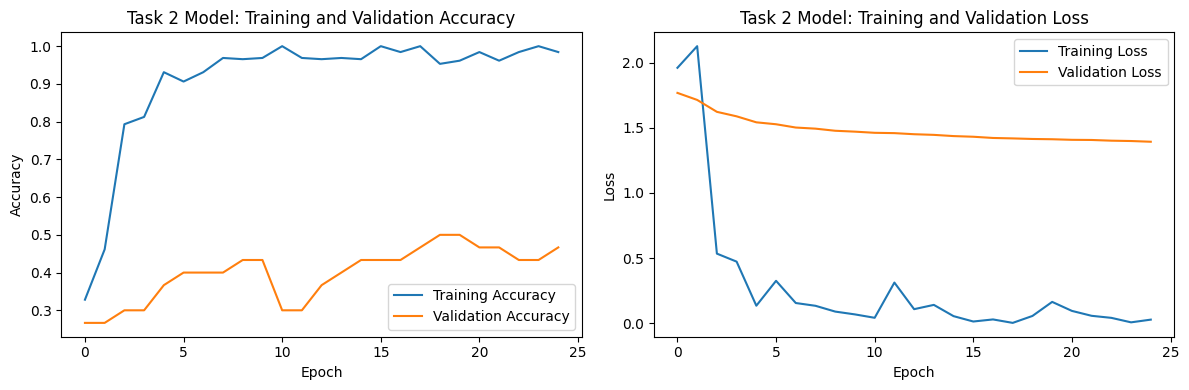

In [17]:
import matplotlib.pyplot as plt

# Plot training history for Task 2 model
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
plt.title('Task 2 Model: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Training Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')
plt.title('Task 2 Model: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
# Evaluate the Task 2 model on the validation set
print("\nEvaluating Task 2 Model on Validation Set")
loss_task2, accuracy_task2 = model.evaluate(validation_generator)
print(f"Task 2 Validation Loss: {loss_task2:.4f}")
print(f"Task 2 Validation Accuracy: {accuracy_task2:.4f}")


Evaluating Task 2 Model on Validation Set
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.4667 - loss: 1.3931
Task 2 Validation Loss: 1.3931
Task 2 Validation Accuracy: 0.4667
